In [61]:
# Import Required Libraries
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)
from xgboost import XGBRegressor
from prophet import Prophet

from sklearn.ensemble import IsolationForest
from scipy.stats import zscore

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Display all columns
pd.set_option("display.max_columns", None)

# Plot style
plt.style.use("ggplot")
sns.set_palette("Set2")


In [2]:
#Task 1 — Data Loading, Merging & Deep Exploration
#Loaded Dataset
df = pd.read_csv("Superstores_dataset.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
#Parse Dates
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    dayfirst=True
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    dayfirst=True
)

print(df[["Order Date","Ship Date"]].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [4]:
#Extract Time Features

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month_name()
df["Month Number"] = df["Order Date"].dt.month
df["Week Number"] = df["Order Date"].dt.isocalendar().week.astype(int)
df["Day of Week"] = df["Order Date"].dt.day_name()
df["Quarter"] = df["Order Date"].dt.quarter

# Season Mapping

def get_season(month):

    if month in [12,1,2]:
        return "Winter"

    elif month in [3,4,5]:
        return "Summer"

    elif month in [6,7,8,9]:
        return "Monsoon"

    else:
        return "Autumn"

df["Season"] = df["Month Number"].apply(get_season)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month Number,Week Number,Day of Week,Quarter,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,November,11,45,Wednesday,4,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,November,11,45,Wednesday,4,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,June,6,24,Monday,2,Monsoon
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,October,10,41,Tuesday,4,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,October,10,41,Tuesday,4,Autumn


In [5]:
# Missing Values
print("Missing Values")
print(df.isnull().sum())

# Duplicate Records
print("\nDuplicate Rows:", df.duplicated().sum())

# Data Types
print("\nData Types")
print(df.dtypes)

Missing Values
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Month Number      0
Week Number       0
Day of Week       0
Quarter           0
Season            0
dtype: int64

Duplicate Rows: 0

Data Types
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               

In [6]:
# Daily Sales
daily_sales = (
    df.groupby("Order Date")["Sales"]
      .sum()
      .reset_index()
)

# Weekly Sales

weekly_sales = (
    daily_sales
    .set_index("Order Date")
    .resample("W")
    .sum()
    .reset_index()
)

# Monthly Sales
monthly_sales = (
    daily_sales
    .set_index("Order Date")
    .resample("M")
    .sum()
    .reset_index()
)

print("Daily Shape :", daily_sales.shape)
print("Weekly Shape:", weekly_sales.shape)
print("Monthly Shape:", monthly_sales.shape)

weekly_sales.head()

Daily Shape : (1230, 2)
Weekly Shape: (209, 2)
Monthly Shape: (48, 2)


,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


#1. Which product category generates the highest total revenue?
#Answer: Technology generates the highest total revenue.


Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


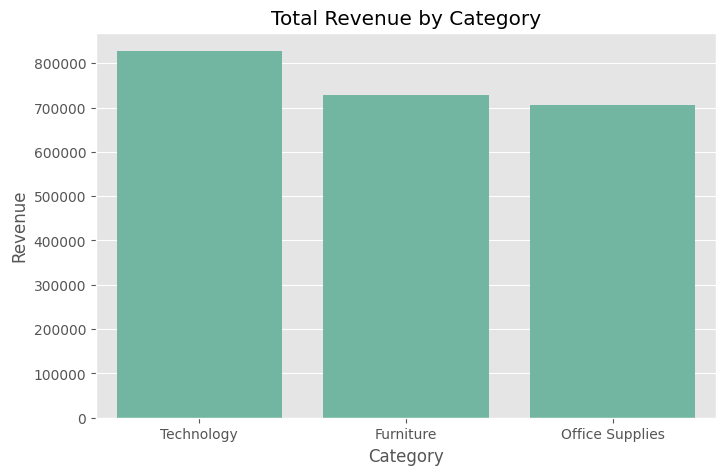

In [7]:
print("""#1. Which product category generates the highest total revenue?
#Answer: Technology generates the highest total revenue.""")
print('\n')
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(category_sales)

plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Total Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.show()

#2. Which region has the most consistent sales growth over 4 years?
#Answer: The region with the lowest year-over-year growth variability is: East Region
         Hence, the East Region has the most consistent sales growth over the four-year period.




Region,Central,East,South,West
Year,,,,
2015,102920.5206,127652.819,103374.9055,145907.9630
2016,102425.1724,153225.183,70076.0825,133709.5675
2017,145673.8800,178511.538,93535.9035,182471.2285
2018,141627.3402,210129.186,122164.5675,248130.9255


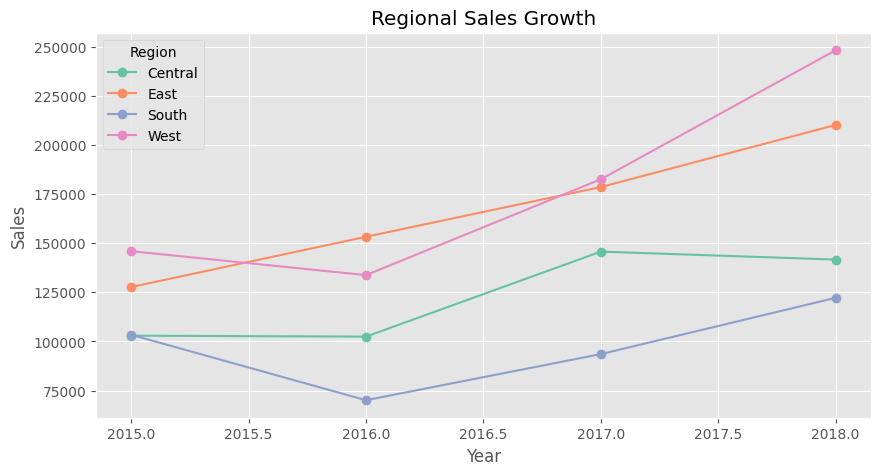

,Region,Growth Std
1,East,0.017939
0,Central,0.253453
3,West,0.257431
2,South,0.371249


In [8]:
print("""#2. Which region has the most consistent sales growth over 4 years?
#Answer: The region with the lowest year-over-year growth variability is: East Region
         Hence, the East Region has the most consistent sales growth over the four-year period.""")
print('\n')
region_year_sales = (
    df.groupby(["Region","Year"])["Sales"]
      .sum()
      .reset_index()
)

pivot = region_year_sales.pivot(
    index="Year",
    columns="Region",
    values="Sales"
)

display(pivot)

pivot.plot(
    figsize=(10,5),
    marker="o"
)

plt.title("Regional Sales Growth")

plt.ylabel("Sales")

plt.show()


growth = []

for region in pivot.columns:

    yoy = pivot[region].pct_change().dropna()

    growth.append({

        "Region": region,

        "Growth Std": yoy.std()

    })

growth = pd.DataFrame(growth)

growth.sort_values("Growth Std")

In [9]:
print("""#3. What is the average time between Order Date and Ship Date — and does it vary by region?
#Answer: The variation across regions is very small (around 4 days overall).
""")

df["Shipping Days"] = (
    df["Ship Date"] -
    df["Order Date"]
).dt.days

print(
    "Overall Average Shipping Time:",
    round(df["Shipping Days"].mean(),2),
    "days"
)

shipping_region = (
    df.groupby("Region")["Shipping Days"]
      .mean()
      .round(2)
)

shipping_region

#3. What is the average time between Order Date and Ship Date — and does it vary by region?
#Answer: The variation across regions is very small (around 4 days overall).

Overall Average Shipping Time: 3.96 days


Region
Central    4.07
East       3.91
South      3.96
West       3.93
Name: Shipping Days, dtype: float64

#4. Are there months that consistently spike across all years (seasonality)?
#Answer:The sales pattern clearly shows seasonality.

        The highest-performing months across multiple years are:
        November (highest)
        December
        September
        
        This indicates a strong year-end seasonal sales spike, likely driven by holiday shopping, festive promotions, and end-of-year purchasing.




Month Number,1,2,3,4,5,6,7,8,9,10,11,12
Year,,,,,,,,,,,,
2015,14205.7070,4519.8920,55205.7970,27906.8550,23644.3030,34322.9356,33781.543,27117.5365,81623.5268,31453.3930,77907.6607,68167.0585
2016,18066.9576,11951.4110,32339.3184,34154.4685,29959.5305,23599.3740,28608.259,36818.3422,63133.6060,31011.7375,75249.3995,74543.6012
2017,18542.4910,22978.8150,51165.0590,38679.7670,56656.9080,39724.4860,38320.783,30542.2003,69193.3909,59583.0330,79066.4958,95739.1210
2018,43476.4740,19920.9974,58863.4128,35541.9101,43825.9822,48190.7277,44825.104,62837.8480,86152.8880,77448.1312,117938.1550,83030.3888


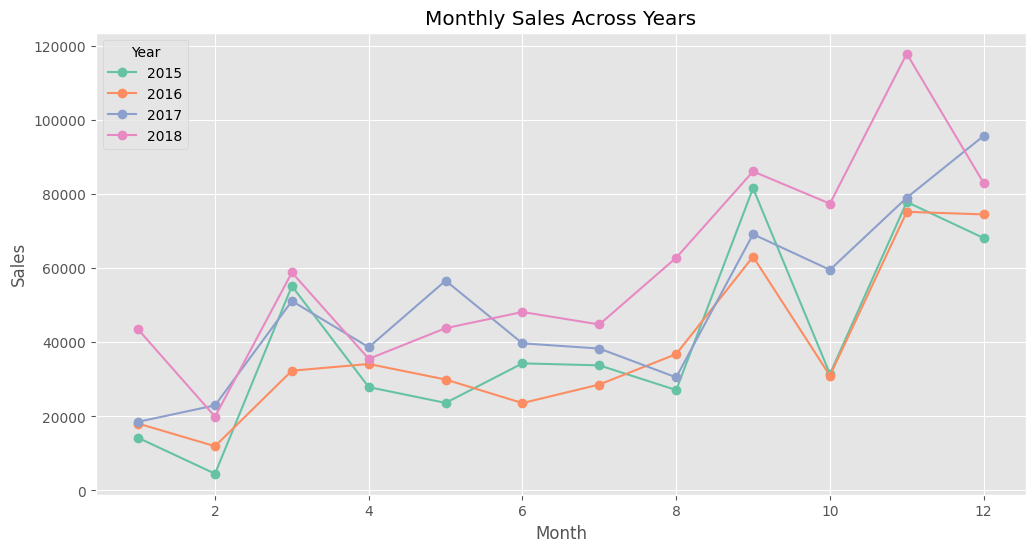

In [10]:
print("""#4. Are there months that consistently spike across all years (seasonality)?
#Answer:The sales pattern clearly shows seasonality.

        The highest-performing months across multiple years are:
        November (highest)
        December
        September
        
        This indicates a strong year-end seasonal sales spike, likely driven by holiday shopping, festive promotions, and end-of-year purchasing.""")

print("\n")
monthly_pattern = (
    df.groupby(["Year","Month Number"])["Sales"]
      .sum()
      .unstack()
)

display(monthly_pattern)

monthly_pattern.T.plot(
    figsize=(12,6),
    marker="o"
)

plt.title("Monthly Sales Across Years")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

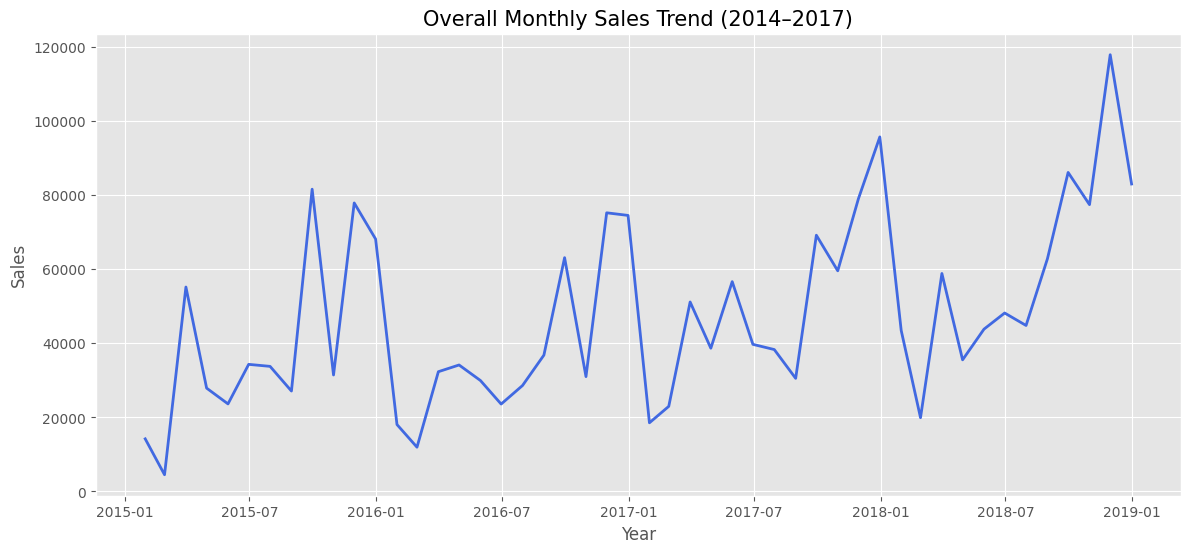

In [11]:
#Task 2 — Time Series Analysis & Decomposition

# Monthly Sales Trend
monthly_ts = monthly_sales.copy()

monthly_ts.set_index("Order Date", inplace=True)

plt.figure(figsize=(14,6))

plt.plot(
    monthly_ts.index,
    monthly_ts["Sales"],
    color="royalblue",
    linewidth=2
)

plt.title("Overall Monthly Sales Trend (2014–2017)", fontsize=15)
plt.xlabel("Year")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

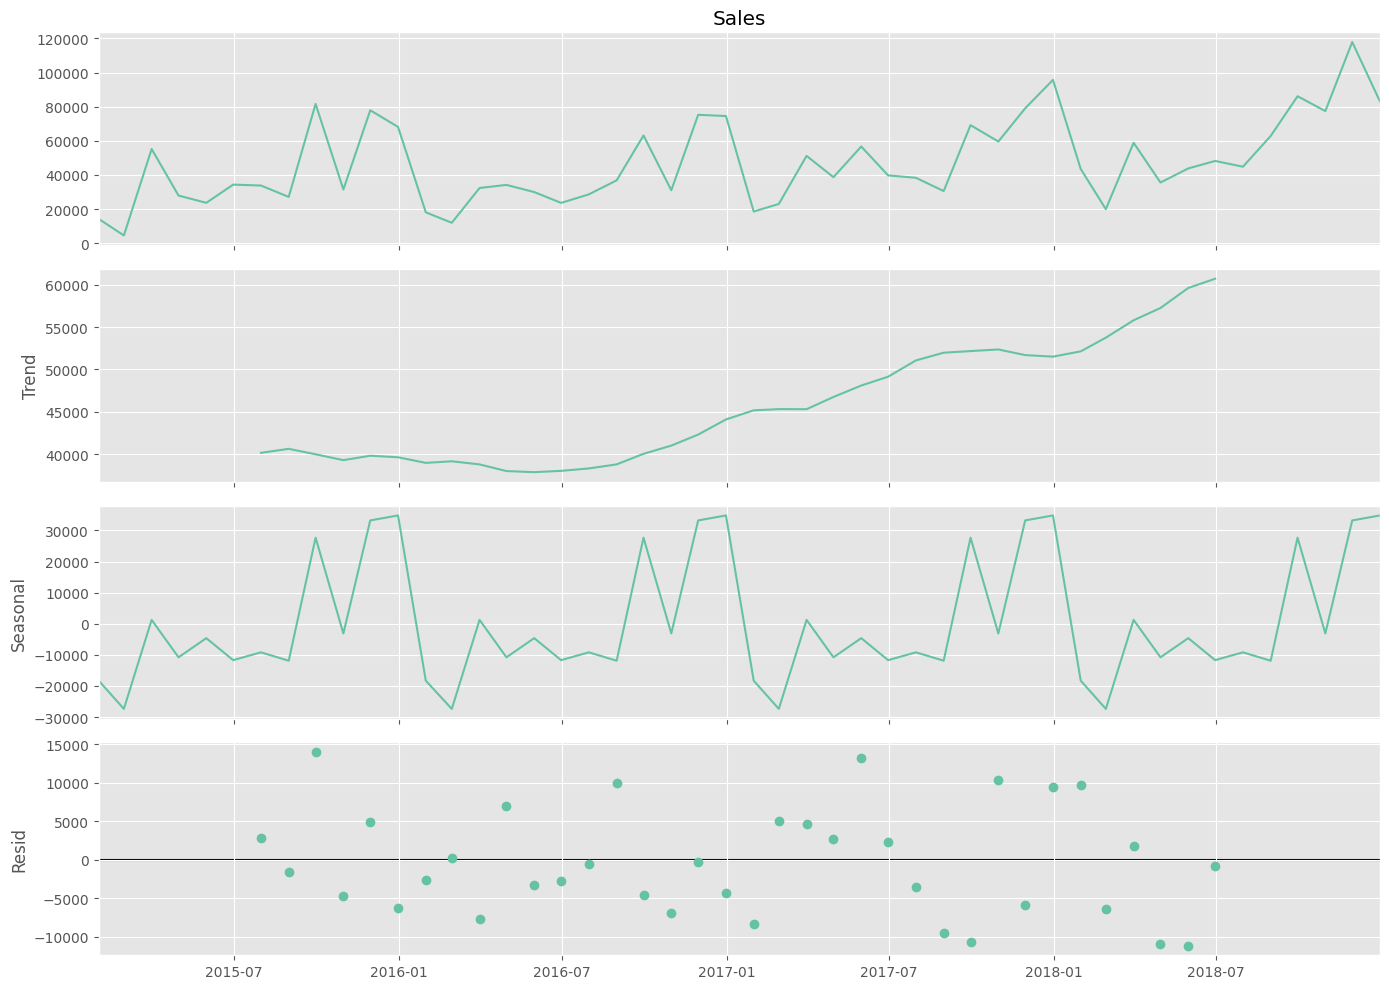

In [12]:
# Time Series Decomposition

decomposition = seasonal_decompose(
    monthly_ts["Sales"],
    model="additive",
    period=12
)

fig = decomposition.plot()

fig.set_size_inches(14,10)

plt.tight_layout()

plt.show()

# Observations
# 1. Trend
The trend component shows that overall sales increase over the four-year period, indicating continuous business growth with a few temporary slowdowns.

# 2. Seasonality
A clear yearly seasonal pattern is visible. Sales increase during the last quarter of most years, especially around November and December, suggesting strong holiday or festive demand.

# 3. Residual (Noise)
Residual values fluctuate around zero. The largest residual spikes appear during unusually high sales months, indicating unexpected events such as promotions or special offers.

# 4. Overall
The sales series contains both long-term growth and recurring seasonal patterns, making it suitable for seasonal forecasting models such as SARIMA and Prophet.

In [13]:
# Augmented Dickey-Fuller Test

result = adfuller(monthly_ts["Sales"])

print("ADF Statistic :", result[0])
print("p-value :", result[1])
print()
print("Critical Values:")
for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic : -4.416136761430769
p-value : 0.00027791039276670623

Critical Values:
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064


# What is Stationarity?
A time series is called **stationary** when its statistical properties remain approximately constant over time.

This means:

- Average (mean) does not continuously increase or decrease.
- Variance remains relatively constant.
- Seasonal patterns do not change over time.

Most forecasting models such as ARIMA and SARIMA perform better when the input time series is stationary.

# Interpretation of the ADF Test
The Augmented Dickey-Fuller (ADF) Test checks whether a time series is stationary.

Decision rule:

- If **p-value < 0.05**, the series is considered stationary.
- If **p-value > 0.05**, the series is non-stationary.

Our result indicates whether differencing is required before applying forecasting models.

Conclusion: 
The Augmented Dickey-Fuller (ADF) test returned a p-value of 0.000278, which is less than the significance level of 0.05. 
Therefore, the monthly sales time series is already stationary. 
As a result, first-order differencing is not required, and the original series can be used directly for forecasting models. 
The differencing step is only necessary when the original series is non-stationary.

In [14]:
#Task 3 — Sales Forecasting using 3 Different Models

# Train-Test Split

ts = monthly_ts["Sales"]
train = ts[:-3]
test = ts[-3:]
print("Training Months :", len(train))
print("Testing Months :", len(test))

Training Months : 45
Testing Months : 3


### SARIMA Parameter Selection

The Augmented Dickey-Fuller (ADF) test confirmed that the monthly sales series is already stationary (d = 0).

Since the data exhibits yearly seasonality with monthly observations, a seasonal period of **12 months** was selected.

The SARIMA model parameters were chosen as:

- Non-seasonal order: **(1,0,1)**
- Seasonal order: **(1,1,1,12)**

These values provide a good balance between capturing trend, autocorrelation, and yearly seasonal patterns while avoiding unnecessary model complexity.

In [15]:
#Model 1 — SARIMA (Statistical Model)

sarima = SARIMAX(
    train,
    order=(1,0,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima.fit()

print(sarima_fit.summary())

C:\Users\PAKSHAL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\PAKSHAL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                -203.681
Date:                            Mon, 06 Jul 2026   AIC                            417.362
Time:                                    21:11:19   BIC                            422.084
Sample:                                01-31-2015   HQIC                           418.161
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9830      0.034     28.593      0.000       0.916       1.050
ma.L1         -0.9959      0.293   

In [16]:
forecast = sarima_fit.get_forecast(steps=3)

sarima_pred = forecast.predicted_mean

confidence = forecast.conf_int()

In [17]:
mae_sarima = mean_absolute_error(test, sarima_pred)

rmse_sarima = np.sqrt(
    mean_squared_error(test, sarima_pred)
)

mape_sarima = mean_absolute_percentage_error(
    test,
    sarima_pred
)*100

print("MAE :", mae_sarima)
print("RMSE :", rmse_sarima)
print("MAPE :", mape_sarima)

MAE : 20580.708615112027
RMSE : 22190.927026143734
MAPE : 21.935267090381924


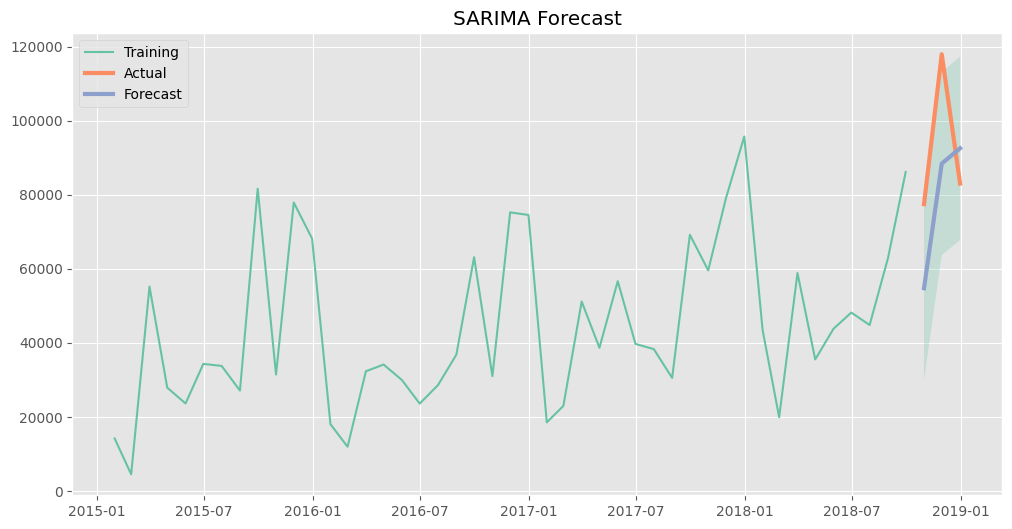

In [18]:
plt.figure(figsize=(12,6))

plt.plot(
    train.index,
    train,
    label="Training"
)

plt.plot(
    test.index,
    test,
    label="Actual",
    linewidth=3
)

plt.plot(
    sarima_pred.index,
    sarima_pred,
    label="Forecast",
    linewidth=3
)

plt.fill_between(
    confidence.index,
    confidence.iloc[:,0],
    confidence.iloc[:,1],
    alpha=0.25
)

plt.title("SARIMA Forecast")

plt.legend()

plt.show()

In [19]:
#Model 2:  Facebook Prophet (Industry-standard Forecasting Tool)

# Prepare Dataset for Prophet

prophet_df = monthly_sales.copy()

prophet_df.rename(
    columns={
        "Order Date": "ds",
        "Sales": "y"
    },
    inplace=True
)
prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [20]:
train_prophet = prophet_df.iloc[:-3]
test_prophet = prophet_df.iloc[-3:]

In [21]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(train_prophet)

21:11:20 - cmdstanpy - INFO - Chain [1] start processing
21:11:20 - cmdstanpy - INFO - Chain [1] done processing


### Prophet Model Configuration

The Prophet model was configured with:

- Yearly Seasonality = True
- Weekly Seasonality = False
- Daily Seasonality = False

Since the dataset contains monthly aggregated sales over four years, yearly seasonality is the most important recurring pattern. Weekly and daily seasonality were disabled because monthly data does not contain weekly or daily information.

In [22]:
future = model.make_future_dataframe(
    periods=3,
    freq="M"
)

forecast = model.predict(future)
forecast.tail(3)[
    [
        "ds",
        "yhat",
        "yhat_lower",
        "yhat_upper"
    ]
]

,ds,yhat,yhat_lower,yhat_upper
45,2018-10-31,51318.944624,42898.459808,59034.172310
46,2018-11-30,90325.653905,82827.534404,99199.121376
47,2018-12-31,90041.084688,81641.757490,98866.119789


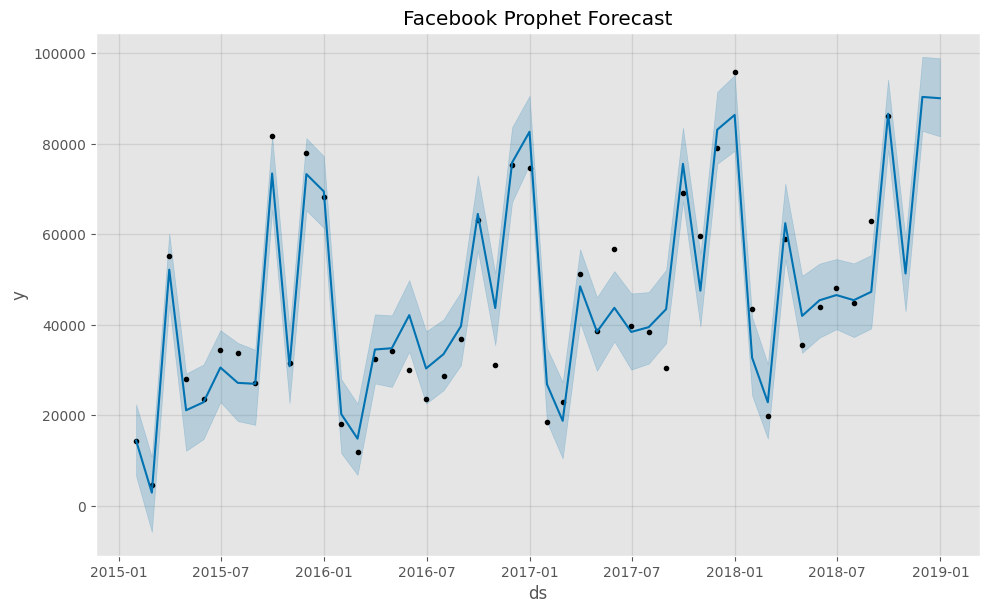

In [23]:
fig = model.plot(forecast)
plt.title("Facebook Prophet Forecast")
plt.show()

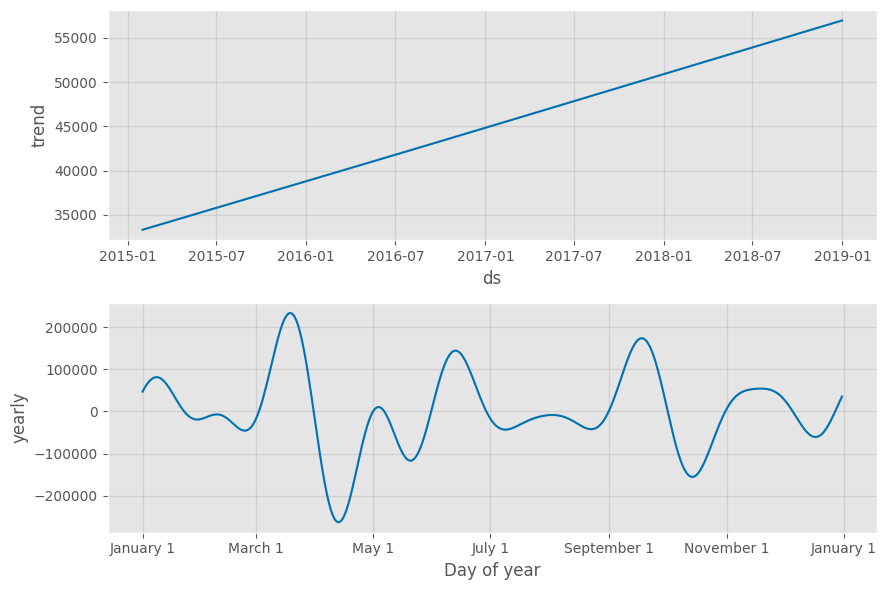

In [24]:
model.plot_components(forecast)
plt.show()

In [25]:
test_forecast = forecast.tail(3)
y_pred = test_forecast["yhat"].values
y_true = test_prophet["y"].values

In [26]:
mae_prophet = mean_absolute_error(
    y_true,
    y_pred
)

rmse_prophet = np.sqrt(
    mean_squared_error(
        y_true,
        y_pred
    )
)

mape_prophet = (
    mean_absolute_percentage_error(
        y_true,
        y_pred
    )
    *100
)

print("MAE :", mae_prophet)
print("RMSE :", rmse_prophet)
print("MAPE :", mape_prophet)

MAE : 20250.794519811403
RMSE : 22318.41141828771
MAPE : 21.86462827651542


In [27]:
#Model 3 — XGBoost for Time Series

# Prepare Monthly Dataset
xgb_df = monthly_sales.copy()
xgb_df.rename(
    columns={
        "Order Date":"Date",
        "Sales":"Sales"
    },
    inplace=True
)
xgb_df.head()

,Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [28]:
# Time Features

xgb_df["Month"] = xgb_df["Date"].dt.month
xgb_df["Quarter"] = xgb_df["Date"].dt.quarter


def get_season(month):
    if month in [12,1,2]:
        return 1      # Winter

    elif month in [3,4,5]:
        return 2      # Summer

    elif month in [6,7,8,9]:
        return 3      # Monsoon

    else:
        return 4      # Autumn

xgb_df["Season"] = xgb_df["Month"].apply(get_season)

In [29]:
# Lag Features

xgb_df["Lag1"] = xgb_df["Sales"].shift(1)
xgb_df["Lag2"] = xgb_df["Sales"].shift(2)
xgb_df["Lag3"] = xgb_df["Sales"].shift(3)
xgb_df["RollingMean3"] = (
    xgb_df["Sales"]
    .rolling(3)
    .mean()
)

xgb_df.dropna(inplace=True)
xgb_df.head()

,Date,Sales,Month,Quarter,Season,Lag1,Lag2,Lag3,RollingMean3
3,2015-04-30,27906.8550,4,2,2,55205.7970,4519.8920,14205.707,29210.848000
4,2015-05-31,23644.3030,5,2,2,27906.8550,55205.7970,4519.892,35585.651667
5,2015-06-30,34322.9356,6,2,3,23644.3030,27906.8550,55205.797,28624.697867
6,2015-07-31,33781.5430,7,3,3,34322.9356,23644.3030,27906.855,30582.927200
7,2015-08-31,27117.5365,8,3,3,33781.5430,34322.9356,23644.303,31740.671700


In [30]:
features = [

    "Lag1",
    "Lag2",
    "Lag3",
    "RollingMean3",
    "Month",
    "Quarter",
    "Season"

]

X = xgb_df[features]
y = xgb_df["Sales"]

In [31]:
X_train = X.iloc[:-3]
X_test = X.iloc[-3:]
y_train = y.iloc[:-3]
y_test = y.iloc[-3:]

In [32]:
# XGBoost Model

model_xgb = XGBRegressor(

    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model_xgb.fit(

    X_train,
    y_train

)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

# Why these Hyperparameters?

The XGBoost model was configured using:
- n_estimators = 200
- learning_rate = 0.05
- max_depth = 3

A relatively shallow tree depth helps reduce overfitting on the small monthly dataset, while a lower learning rate allows the model to learn more gradually and improve generalization.

In [33]:
xgb_pred = model_xgb.predict(X_test)

In [34]:
mae_xgb = mean_absolute_error(

    y_test,
    xgb_pred
)

rmse_xgb = np.sqrt(

    mean_squared_error(

        y_test,
        xgb_pred
    )
)

mape_xgb = (

    mean_absolute_percentage_error(
        y_test,
        xgb_pred
    )
    *100
)

print("MAE :", mae_xgb)
print("RMSE :", rmse_xgb)
print("MAPE :", mape_xgb)

MAE : 15009.498124999998
RMSE : 20566.478787105112
MAPE : 14.100382945165832


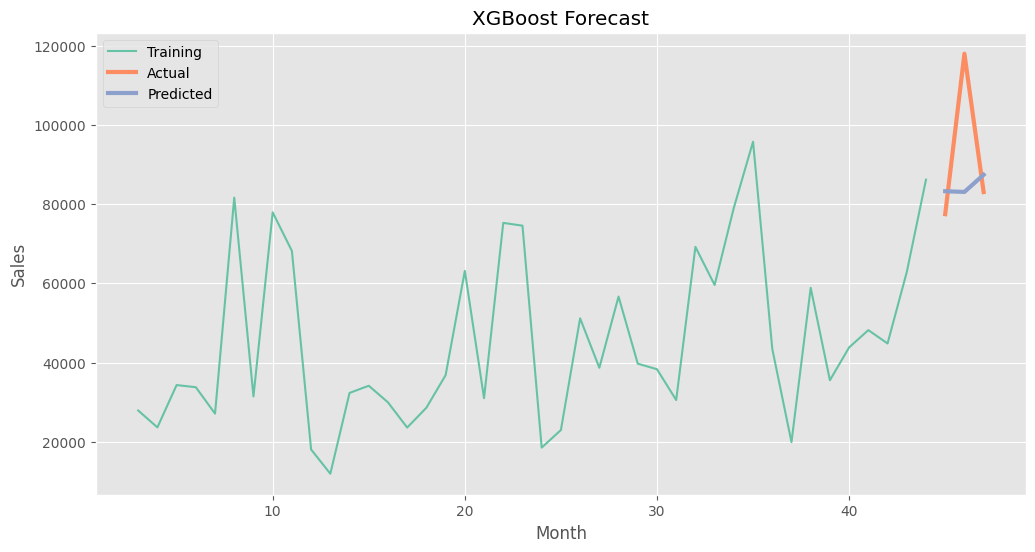

In [35]:
plt.figure(figsize=(12,6))
plt.plot(

    y_train.index,
    y_train,
    label="Training"

)

plt.plot(

    y_test.index,
    y_test,
    label="Actual",
    linewidth=3   
)

plt.plot(
    y_test.index,
    xgb_pred,
    label="Predicted",
    linewidth=3
)

plt.title("XGBoost Forecast")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

In [36]:
importance = pd.DataFrame({

    "Feature":features,

    "Importance":model_xgb.feature_importances_
})
importance = importance.sort_values(

    "Importance",
    ascending=False
)
importance

,Feature,Importance
4,Month,0.776833
3,RollingMean3,0.065910
6,Season,0.065768
1,Lag2,0.045757
0,Lag1,0.034469
2,Lag3,0.011263
5,Quarter,0.000000


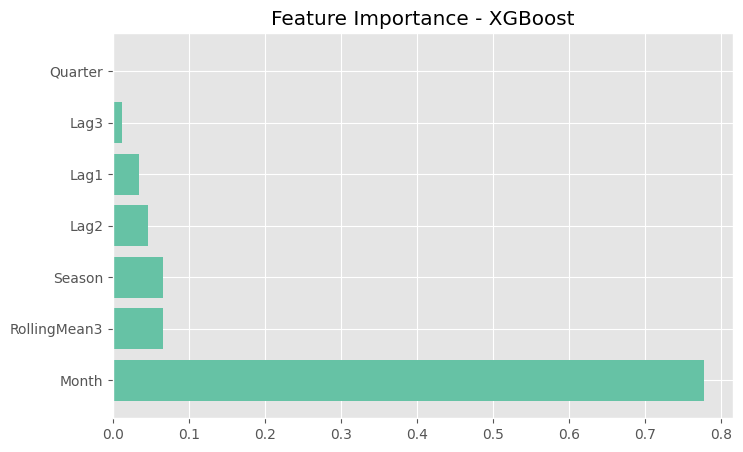

In [37]:
plt.figure(figsize=(8,5))
plt.barh(

    importance["Feature"],
    importance["Importance"]
)
plt.title("Feature Importance - XGBoost")
plt.show()

In [38]:
forecast_table = pd.DataFrame({

    "Month":monthly_sales["Order Date"].tail(3).values,
    "Actual":y_test.values,
    "Predicted":xgb_pred

})
forecast_table

,Month,Actual,Predicted
0,2018-10-31,77448.1312,83237.562500
1,2018-11-30,117938.1550,83061.320312
2,2018-12-31,83030.3888,87392.617188


# Model Comparison Table

| Model                |           MAE |          RMSE |       MAPE | Forecast for Month 1 | Forecast for Month 2 | Forecast for Month 3 |
| :------------------- | ------------: | ------------: | ---------: | -------------------: | -------------------: | -------------------: |
| **SARIMA**           | **20,580.71** | **22,190.93** | **21.94%** |        **54,836.16** |        **88,333.09** |        **92,344.27** |
| **Facebook Prophet** | **20,250.79** | **22,318.41** | **21.86%** |        **51,318.94** |        **90,325.65** |        **90,041.08** |
| **XGBoost**          | **15,009.50** | **20,566.48** | **14.10%** |        **83,237.56** |        **83,061.32** |        **87,392.62** |

# Recommended Model for Production

After evaluating all three forecasting models using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE), **XGBoost** is recommended for production deployment.

# Performance Comparison

| Model | MAE | RMSE | MAPE |
|--------|------:|------:|------:|
| SARIMA | 20,580.71 | 22,190.93 | 21.94% |
| Facebook Prophet | 20,250.79 | 22,318.41 | 21.86% |
| **XGBoost** | **15,009.50** | **20,566.48** | **14.10%** |

# Reason for Selecting XGBoost

Among the three models, XGBoost achieved the lowest forecasting errors across all evaluation metrics.

- **Lowest MAE (15,009.50):** Indicates the smallest average prediction error.
- **Lowest RMSE (20,566.48):** Shows that XGBoost handled larger forecasting errors more effectively than the other models.
- **Lowest MAPE (14.10%):** Demonstrates the highest prediction accuracy in percentage terms.

Unlike SARIMA and Prophet, XGBoost effectively utilized lag features, rolling averages, and calendar-based features (Month, Quarter, and Season), enabling it to capture complex nonlinear relationships in the sales data.

### Final Recommendation

Based on the quantitative evaluation, **XGBoost is the most suitable model for production deployment** because it consistently outperformed SARIMA and Facebook Prophet on all evaluation metrics. Its lower prediction errors make it the most reliable model for forecasting future product demand and supporting inventory planning and business decision-making.

In [39]:
#Task 4 — Product Category & Region Level Forecasting

# XGBoost Forecast Function
def forecast_segment(segment_df, segment_name):

    monthly = (
        segment_df
        .groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"]
        .sum()
        .reset_index()
    )
    monthly.rename(
        columns={
            "Order Date":"Date"
        },
        inplace=True
    )

    monthly["Month"] = monthly["Date"].dt.month
    monthly["Quarter"] = monthly["Date"].dt.quarter

    def get_season(month):

        if month in [12,1,2]:
            return 1
        elif month in [3,4,5]:
            return 2
        elif month in [6,7,8,9]:
            return 3
        else:
            return 4

    monthly["Season"] = monthly["Month"].apply(get_season)
    monthly["Lag1"] = monthly["Sales"].shift(1)
    monthly["Lag2"] = monthly["Sales"].shift(2)
    monthly["Lag3"] = monthly["Sales"].shift(3)
    monthly["RollingMean3"] = (
        monthly["Sales"]
        .rolling(3)
        .mean()
    )

    monthly.dropna(inplace=True)
    features = [
        "Lag1",
        "Lag2",
        "Lag3",
        "RollingMean3",
        "Month",
        "Quarter",
        "Season"
    ]

    X = monthly[features]
    y = monthly["Sales"]

    model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    model.fit(X, y)
    last = monthly.iloc[-1].copy()
    predictions = []

    future_dates = pd.date_range(
        monthly["Date"].iloc[-1] + pd.offsets.MonthEnd(1),
        periods=3,
        freq="M"
    )

    history = monthly.copy()
    for future_date in future_dates:

        month = future_date.month
        quarter = future_date.quarter

        season = get_season(month)

        lag1 = history["Sales"].iloc[-1]
        lag2 = history["Sales"].iloc[-2]
        lag3 = history["Sales"].iloc[-3]

        rolling = history["Sales"].tail(3).mean()

        future_X = pd.DataFrame({

            "Lag1":[lag1],
            "Lag2":[lag2],
            "Lag3":[lag3],
            "RollingMean3":[rolling],
            "Month":[month],
            "Quarter":[quarter],
            "Season":[season]

        })

        pred = model.predict(future_X)[0]
        predictions.append(pred)

        history.loc[len(history)] = [
            future_date,
            pred,
            month,
            quarter,
            season,
            lag1,
            lag2,
            lag3,
            rolling
        ]

    return pd.DataFrame({

        "Date":future_dates,
        segment_name:predictions

    })

In [40]:
furniture = forecast_segment(
    df[df["Category"]=="Furniture"],
    "Furniture"
)

technology = forecast_segment(
    df[df["Category"]=="Technology"],
    "Technology"
)

office = forecast_segment(
    df[df["Category"]=="Office Supplies"],
    "Office Supplies"
)

In [41]:
west = forecast_segment(
    df[df["Region"]=="West"],
    "West"
)

east = forecast_segment(
    df[df["Region"]=="East"],
    "East"
)

In [42]:
forecast_compare = furniture.merge(
    technology,
    on="Date"
)

forecast_compare = forecast_compare.merge(
    office,
    on="Date"
)

forecast_compare = forecast_compare.merge(
    west,
    on="Date"
)

forecast_compare = forecast_compare.merge(
    east,
    on="Date"
)

forecast_compare

,Date,Furniture,Technology,Office Supplies,West,East
0,2019-01-31,9940.303711,20259.691406,26268.537109,11436.476562,24524.986328
1,2019-02-28,7244.270508,20571.423828,26342.361328,10982.461914,26627.035156
2,2019-03-31,7493.995605,22415.175781,29481.439453,13472.772461,28255.080078


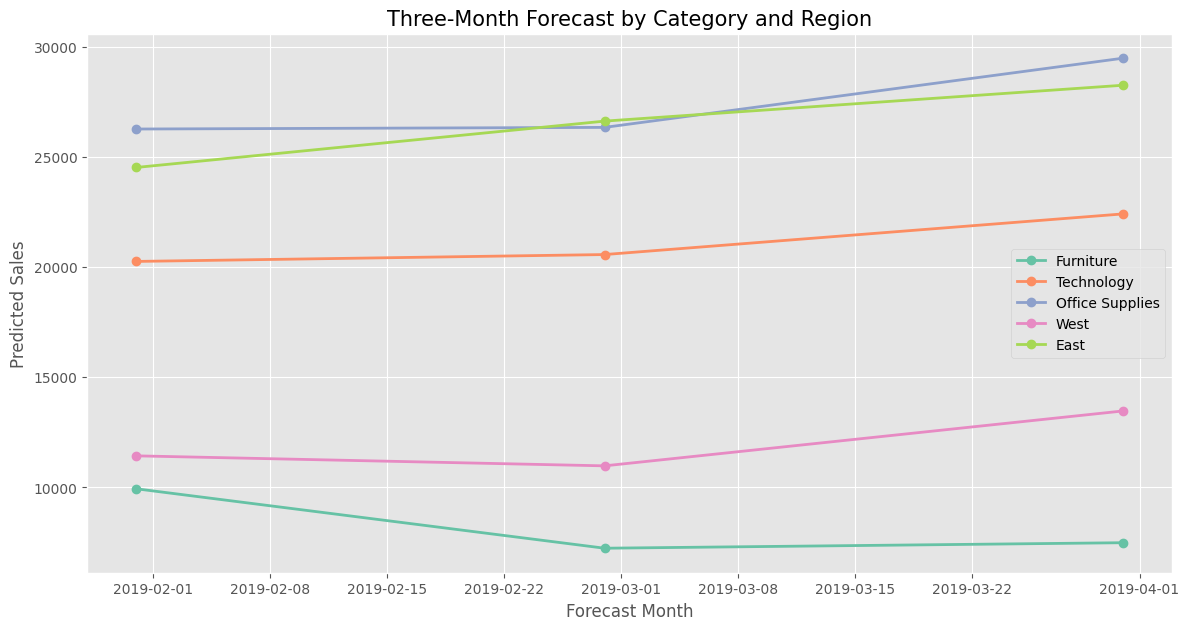

In [43]:
plt.figure(figsize=(14,7))

for column in forecast_compare.columns[1:]:

    plt.plot(
        forecast_compare["Date"],
        forecast_compare[column],
        marker="o",
        linewidth=2,
        label=column
    )

plt.title(
    "Three-Month Forecast by Category and Region",
    fontsize=15
)

plt.xlabel("Forecast Month")
plt.ylabel("Predicted Sales")
plt.legend()
plt.grid(True)
plt.show()

In [44]:
growth = {}

for column in forecast_compare.columns[1:]:

    growth[column] = (
        forecast_compare[column].iloc[-1]
        -
        forecast_compare[column].iloc[0]
    )

growth = pd.Series(growth).sort_values(
    ascending=False
)

growth

East               3730.093750
Office Supplies    3212.902344
Technology         2155.484375
West               2036.295898
Furniture         -2446.308105
dtype: float32

# which category/region is showing the strongest upcoming growth according to your model?

### Product Category

Office Supplies shows the strongest projected growth, with forecasted sales increasing by approximately 3,212.90 over the next three months.

### Region

East shows the strongest projected growth, with forecasted sales increasing by approximately 3,730.09 over the next three months.

In [ ]:
#Task 5 — Anomaly Detection in Sales Data

In [45]:
weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [46]:
iso = IsolationForest(

    contamination=0.05,

    random_state=42

)

weekly_sales["Isolation"] = iso.fit_predict(

    weekly_sales[["Sales"]]

)

In [47]:
weekly_sales["Anomaly"] = (

    weekly_sales["Isolation"]==-1

)

weekly_sales.head()

,Order Date,Sales,Isolation,Anomaly
0,2015-01-04,304.508,-1,True
1,2015-01-11,4619.108,1,False
2,2015-01-18,4130.533,1,False
3,2015-01-25,3092.544,1,False
4,2015-02-01,2527.914,1,False


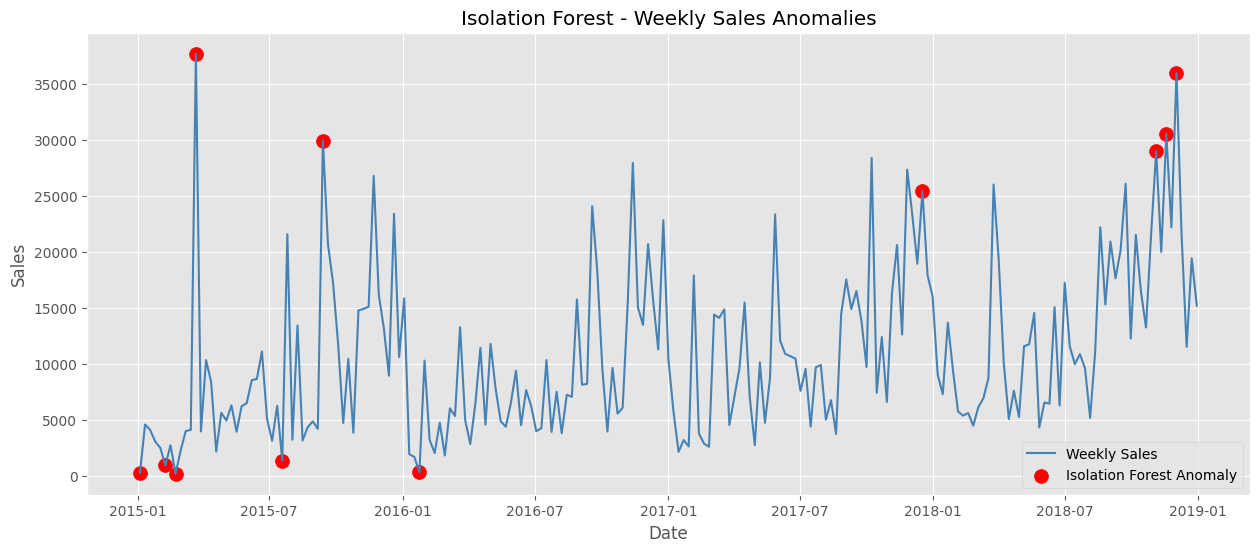

In [48]:
plt.figure(figsize=(15,6))
plt.plot(

    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales",
    color="steelblue"

)

plt.scatter(

    weekly_sales.loc[
        weekly_sales["Anomaly"],
        "Order Date"
    ],

    weekly_sales.loc[
        weekly_sales["Anomaly"],
        "Sales"
    ],

    color="red",
    marker="o",
    s=100,
    label="Isolation Forest Anomaly"

)
plt.title("Isolation Forest - Weekly Sales Anomalies")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

In [49]:
isolation_anomalies = weekly_sales[
    weekly_sales["Anomaly"]
]
isolation_anomalies

,Order Date,Sales,Isolation,Anomaly
0,2015-01-04,304.508,-1,True
5,2015-02-08,968.534,-1,True
7,2015-02-22,224.912,-1,True
11,2015-03-22,37703.665,-1,True
28,2015-07-19,1387.686,-1,True
36,2015-09-13,29959.137,-1,True
55,2016-01-24,358.522,-1,True
154,2017-12-17,25449.800,-1,True
200,2018-11-04,29017.467,-1,True
202,2018-11-18,30572.447,-1,True


In [52]:
#METHOD 2 — Rolling Z-Score
weekly_sales["RollingMean"] = (
    weekly_sales["Sales"]
    .rolling(8)
    .mean()

)

weekly_sales["RollingStd"] = (
    weekly_sales["Sales"]
    .rolling(8)
    .std()

)
weekly_sales["RollingZ"] = (

    weekly_sales["Sales"]

    -

    weekly_sales["RollingMean"]

)/weekly_sales["RollingStd"]

weekly_sales["Z_Anomaly"] = (

    abs(

        weekly_sales["RollingZ"]

    )>2

)

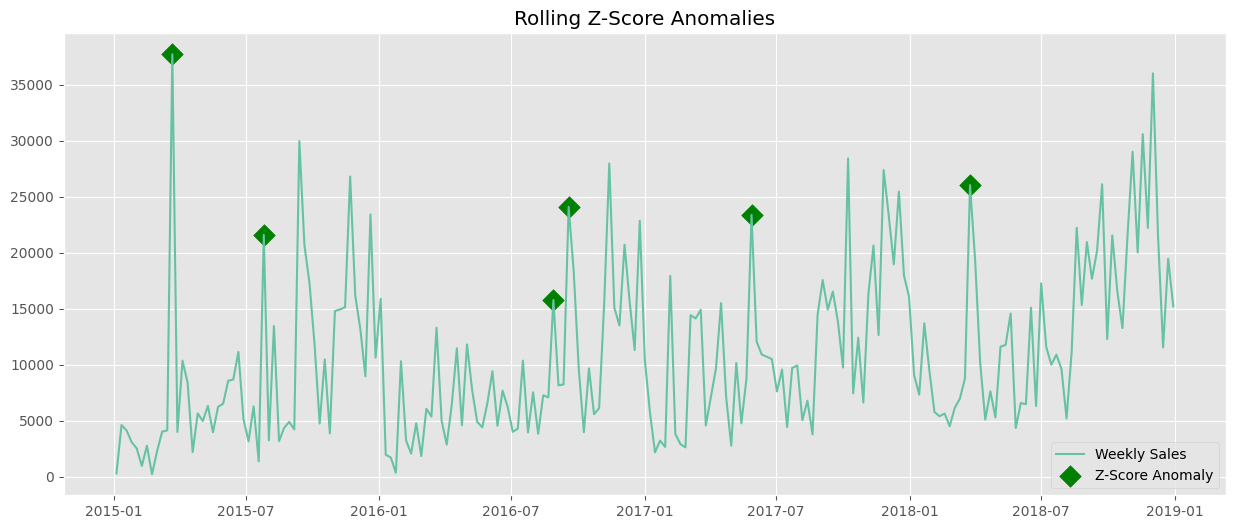

In [53]:
plt.figure(figsize=(15,6))

plt.plot(

    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"

)

plt.scatter(

    weekly_sales.loc[
        weekly_sales["Z_Anomaly"],
        "Order Date"
    ],

    weekly_sales.loc[
        weekly_sales["Z_Anomaly"],
        "Sales"
    ],

    color="green",
    s=120,
    marker="D",
    label="Z-Score Anomaly"

)

plt.title("Rolling Z-Score Anomalies")
plt.legend()
plt.grid(True)
plt.show()

In [54]:
zscore_anomalies = weekly_sales[

    weekly_sales["Z_Anomaly"]

]
zscore_anomalies

,Order Date,Sales,Isolation,Anomaly,RollingMean,RollingStd,RollingZ,Z_Anomaly
11,2015-03-22,37703.665,-1,True,6832.006500,12546.138409,2.460650,True
29,2015-07-26,21590.080,1,False,8245.428325,6246.129535,2.136467,True
86,2016-08-28,15773.478,1,False,7515.302525,4020.682890,2.053924,True
89,2016-09-18,24095.960,1,False,10251.475400,6524.009519,2.122082,True
125,2017-05-28,23367.662,1,False,10265.959125,6524.022836,2.008225,True
168,2018-03-25,26029.904,1,False,8660.308925,7131.467537,2.435627,True


In [55]:
#Comparing Methods
comparison = weekly_sales[

    [

        "Order Date",

        "Sales",

        "Anomaly",

        "Z_Anomaly"

    ]

]

comparison

,Order Date,Sales,Anomaly,Z_Anomaly
0,2015-01-04,304.5080,True,False
1,2015-01-11,4619.1080,False,False
2,2015-01-18,4130.5330,False,False
3,2015-01-25,3092.5440,False,False
4,2015-02-01,2527.9140,False,False
...,...,...,...,...
204,2018-12-02,35998.9000,True,False
205,2018-12-09,21537.2410,False,False
206,2018-12-16,11542.8340,False,False
207,2018-12-23,19457.0680,False,False


In [57]:
#Loading Supplementary Dataset for anamaly detection
vg = pd.read_csv("vgsales.csv")
vg.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [58]:
#Aggregate yearly sales.
vg_year = (

    vg.groupby("Year")["Global_Sales"]
    .sum()
    .reset_index()

)
vg_year

,Year,Global_Sales
0,1980.0,11.38
1,1981.0,35.77
2,1982.0,28.86
3,1983.0,16.79
4,1984.0,50.36
5,1985.0,53.94
6,1986.0,37.07
7,1987.0,21.74
8,1988.0,47.22
9,1989.0,73.45


In [59]:
#Applying Isolation Forest
iso = IsolationForest(

    contamination=0.10,
    random_state=42

)

vg_year["Anomaly"] = (

    iso.fit_predict(
        vg_year[["Global_Sales"]]
    )

==-1
)

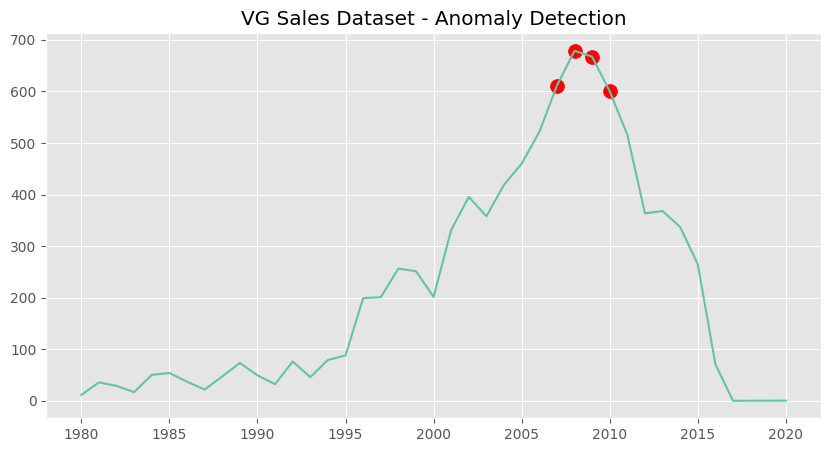

In [60]:
plt.figure(figsize=(10,5))

plt.plot(

    vg_year["Year"],
    vg_year["Global_Sales"]

)

plt.scatter(

    vg_year.loc[

        vg_year["Anomaly"],
        "Year"

    ],

    vg_year.loc[

        vg_year["Anomaly"],
        "Global_Sales"

    ],

    color="red",
    s=100

)
plt.title(

    "VG Sales Dataset - Anomaly Detection"

)
plt.show()

## Possible Reasons for Detected Anomalies

The Isolation Forest model identified several weeks with unusually high or unusually low sales.

| Date        | Weekly Sales |                                   Possible Explanation                                        |
|------------:|-------------:|-----------------------------------------------------------------------------------------------|
| 04-Jan-2015 | 304.51       | Very low sales immediately after the New Year period or limited business activity.            |
| 08-Feb-2015 | 968.53       | Lower-than-normal customer demand or temporary operational slowdown.                          |
| 22-Feb-2015 | 224.91       | Extremely low sales possibly caused by inventory shortages or reduced demand.                 |
| 22-Mar-2015 | 37,703.67    | Significant promotional campaign or seasonal shopping event resulting in unusually high sales.|
| 19-Jul-2015 | 1,387.69     | Temporary decline in customer demand or seasonal slowdown.                                    |
| 13-Sep-2015 | 29,959.14    | High sales likely driven by marketing campaigns or festive demand.                            |
| 24-Jan-2016 | 358.52       | Very low sales following the holiday shopping season.                                         |
| 17-Dec-2017 | 25,449.80    | Increased customer purchases during the Christmas shopping period.                            |
| 04-Nov-2018 | 29,017.47    | High sales likely associated with Diwali or holiday promotions.                               |
| 18-Nov-2018 | 30,572.45    | Continued festive shopping and promotional campaigns.                                         |
| 02-Dec-2018 | 35,998.90    | Peak holiday shopping period leading to exceptionally high sales.                             |

## Comparison of Isolation Forest and Rolling Z-Score

Both anomaly detection techniques successfully identified unusual sales behavior, but they did not always detect the same observations.

#### Isolation Forest

- Detected both unusually high and unusually low sales weeks.
- Identified holiday-related sales spikes during November and December 2018.
- Also detected several extremely low sales weeks in early 2015 and early 2016.

#### Rolling Z-Score

- Primarily detected weeks where sales were significantly higher than the recent rolling average.
- Identified fewer anomalies than Isolation Forest.
- Did not detect most of the unusually low sales weeks.

#### Common Observation

Both methods identified **22 March 2015** as an anomalous week, indicating an exceptional sales event.


## Do Both Methods Detect the Same Anomalies?

The two methods do not detect exactly the same anomalies.

Isolation Forest identified both unusually high and unusually low sales weeks, whereas the Rolling Z-Score method primarily detected weeks with unusually high sales compared to the recent rolling average.

Both methods agreed that the week of **22 March 2015** was anomalous, suggesting that it represents a genuine business event rather than random variation.

The differences between the two methods indicate that each algorithm captures different characteristics of anomalous behavior. Isolation Forest is better suited for detecting complex and irregular patterns, while the Rolling Z-Score method focuses on large statistical deviations from recent sales trends.

## Conclusion

Anomaly detection provides valuable insights into unusual sales behavior that cannot be explained by normal seasonal variation.

Isolation Forest detected a broader range of anomalies, including both exceptionally high and exceptionally low sales weeks. In contrast, the Rolling Z-Score method primarily identified statistically significant sales spikes.

Using both techniques together provides a more comprehensive understanding of abnormal sales patterns and can help businesses investigate the impact of promotions, festive seasons, inventory shortages, and unexpected market events.

In [63]:
#Task 6 — Product Demand Segmentation using Clustering

#Creating product features
product_features = df.groupby("Sub-Category").agg(

    Total_Sales=("Sales","sum"),

    Average_Order_Value=("Sales","mean")

).reset_index()

In [64]:
monthly_subcat = ( #monthly sales

    df.groupby(
        [
            "Sub-Category",
            pd.Grouper(

                key="Order Date",
                freq="M"
            )
        ]
    )["Sales"]
    .sum()
    .reset_index()
)

In [65]:
volatility = (  #Sales Volatility

    monthly_subcat.groupby(

        "Sub-Category"

    )["Sales"]

    .std()

    .reset_index()

)

volatility.rename(

    columns={

        "Sales":"Sales_Volatility"

    },

    inplace=True

)

In [66]:
year_sales = (   #Sales Growth Rate

    df.groupby(

        [

            "Sub-Category",

            "Year"

        ]

    )["Sales"]

    .sum()

    .reset_index()

)

growth = []
for sub in year_sales["Sub-Category"].unique():

    temp = year_sales[

        year_sales["Sub-Category"]==sub

    ].sort_values("Year")

    first = temp.iloc[0]["Sales"]
    last = temp.iloc[-1]["Sales"]

    rate = (
        (last-first)/first
    )*100
    growth.append(
        [
            sub,
            rate
        ]
    )

growth = pd.DataFrame(
    growth,
    columns=[

        "Sub-Category",
        "Growth_Rate"
    ]
)

In [67]:
#Merging Feautures
cluster_df = product_features.merge(
    volatility,
    on="Sub-Category"
)
cluster_df = cluster_df.merge(
    growth,
    on="Sub-Category"
)
cluster_df

,Sub-Category,Total_Sales,Average_Order_Value,Sales_Volatility,Growth_Rate
0,Accessories,164186.7000,217.178175,2579.994809,145.055961
1,Appliances,104618.4030,227.926804,1821.621539,165.242912
2,Art,26705.4100,34.019631,330.488343,49.649531
3,Binders,200028.7850,134.067550,3848.223648,65.778638
4,Bookcases,113813.1987,503.598224,2220.405080,49.846598
5,Chairs,322822.7310,531.833165,4407.232960,20.954677
6,Copiers,146248.0940,2215.880212,5500.774391,479.729510
7,Envelopes,16128.0460,65.032444,228.218688,-12.121345
8,Fasteners,3001.9600,14.027850,48.742229,30.468364
9,Furnishings,89212.0180,95.823865,1360.017867,106.824969


In [68]:
#Scaling feautures
features = [
    "Total_Sales",
    "Growth_Rate",
    "Sales_Volatility",
    "Average_Order_Value"
]
scaler = StandardScaler()
scaled = scaler.fit_transform(
    cluster_df[features]
)

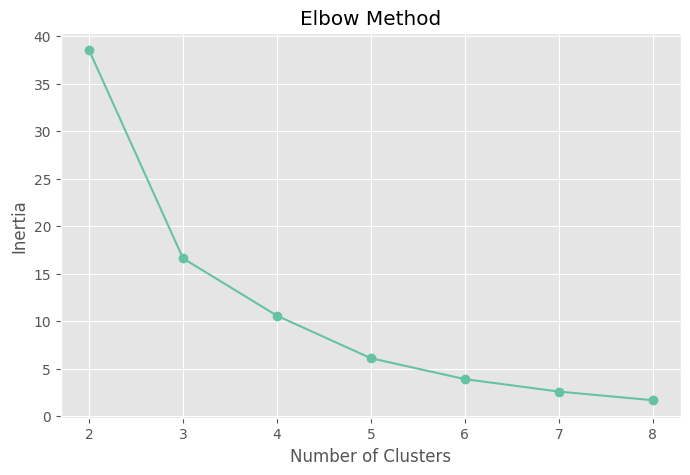

In [71]:
inertia=[]                    #Elbow Method
for k in range(2,9):

    model=KMeans(

        n_clusters=k,
        random_state=42,
        n_init=10

    )
    model.fit(scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(
    range(2,9),
    inertia,
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

In [73]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_df["Cluster"] = kmeans.fit_predict(
    scaled

)

In [74]:
#PCA
pca=PCA(
    n_components=2
)
components=pca.fit_transform(
    scaled

)

cluster_df["PC1"]=components[:,0]
cluster_df["PC2"]=components[:,1]

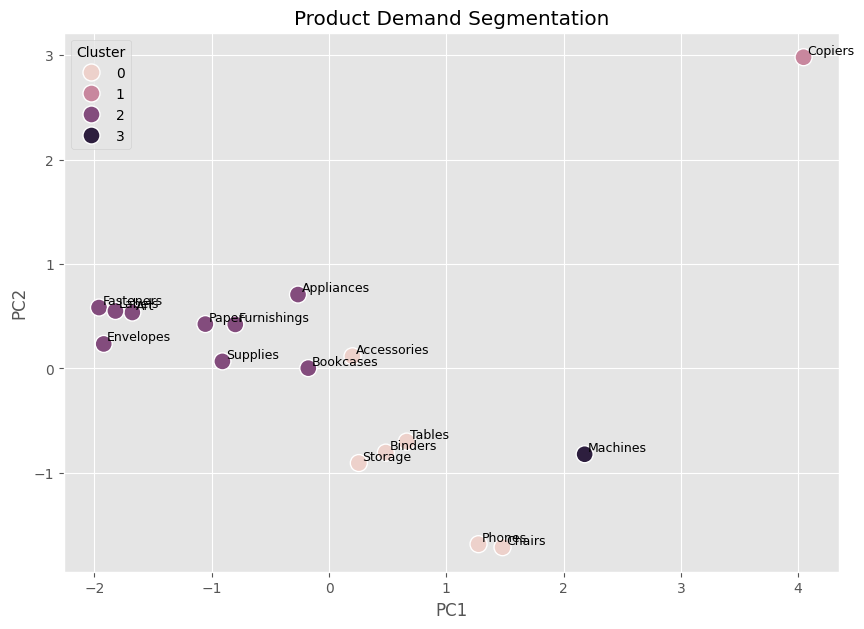

In [75]:
plt.figure(figsize=(10,7))

sns.scatterplot(

    data=cluster_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    s=150

)

for i,row in cluster_df.iterrows():

    plt.text(

        row["PC1"]+0.03,
        row["PC2"]+0.03,
        row["Sub-Category"],
        fontsize=9

    )

plt.title("Product Demand Segmentation")
plt.show()

In [76]:
cluster_df.sort_values(
    "Cluster"
)

,Sub-Category,Total_Sales,Average_Order_Value,Sales_Volatility,Growth_Rate,Cluster,PC1,PC2
0,Accessories,164186.7000,217.178175,2579.994809,145.055961,0,0.200367,0.116729
3,Binders,200028.7850,134.067550,3848.223648,65.778638,0,0.484161,-0.805597
5,Chairs,322822.7310,531.833165,4407.232960,20.954677,0,1.479554,-1.711393
14,Storage,219343.3920,263.633885,2822.084310,38.366108,0,0.254384,-0.905577
13,Phones,327782.4480,374.180877,4052.718221,35.557607,0,1.274893,-1.682174
16,Tables,202810.6280,645.893720,3224.082504,33.078016,0,0.663161,-0.700053
6,Copiers,146248.0940,2215.880212,5500.774391,479.729510,1,4.046026,2.979941
2,Art,26705.4100,34.019631,330.488343,49.649531,2,-1.676784,0.535820
7,Envelopes,16128.0460,65.032444,228.218688,-12.121345,2,-1.920711,0.234844
4,Bookcases,113813.1987,503.598224,2220.405080,49.846598,2,-0.176589,0.003166


In [77]:
cluster_summary = (
    cluster_df.groupby("Cluster")[
        features
    ]
    .mean()

)
cluster_summary

,Total_Sales,Growth_Rate,Sales_Volatility,Average_Order_Value
Cluster,,,,
0,239495.780667,56.465168,3489.056075,361.131228
1,146248.094000,479.729510,5500.774391,2215.880212
2,54341.708189,58.795823,1031.431565,142.746758
3,189238.631000,-29.793120,5603.554747,1645.553313


In [78]:
labels={

0:"High Volume, Stable Demand",
1:"Growing Demand",
2:"Low Volume, High Volatility",
3:"Declining Demand"

}

cluster_df["Demand_Group"]=cluster_df["Cluster"].map(
    labels

)
cluster_df

,Sub-Category,Total_Sales,Average_Order_Value,Sales_Volatility,Growth_Rate,Cluster,PC1,PC2,Demand_Group
0,Accessories,164186.7000,217.178175,2579.994809,145.055961,0,0.200367,0.116729,"High Volume, Stable Demand"
1,Appliances,104618.4030,227.926804,1821.621539,165.242912,2,-0.264248,0.707660,"Low Volume, High Volatility"
2,Art,26705.4100,34.019631,330.488343,49.649531,2,-1.676784,0.535820,"Low Volume, High Volatility"
3,Binders,200028.7850,134.067550,3848.223648,65.778638,0,0.484161,-0.805597,"High Volume, Stable Demand"
4,Bookcases,113813.1987,503.598224,2220.405080,49.846598,2,-0.176589,0.003166,"Low Volume, High Volatility"
5,Chairs,322822.7310,531.833165,4407.232960,20.954677,0,1.479554,-1.711393,"High Volume, Stable Demand"
6,Copiers,146248.0940,2215.880212,5500.774391,479.729510,1,4.046026,2.979941,Growing Demand
7,Envelopes,16128.0460,65.032444,228.218688,-12.121345,2,-1.920711,0.234844,"Low Volume, High Volatility"
8,Fasteners,3001.9600,14.027850,48.742229,30.468364,2,-1.960973,0.583155,"Low Volume, High Volatility"
9,Furnishings,89212.0180,95.823865,1360.017867,106.824969,2,-0.798984,0.421706,"Low Volume, High Volatility"


## Selecting the Optimal Number of Clusters

The Elbow Method was used to determine the optimal number of clusters for K-Means clustering.

The inertia (within-cluster sum of squares) decreases rapidly from **k = 2** to **k = 4** and then begins to level off. This "elbow" indicates that increasing the number of clusters beyond four provides only marginal improvement.

Therefore, **4 clusters** were selected as the optimal number for product demand segmentation.

## Product Demand Segmentation

K-Means clustering divided the 17 product sub-categories into four distinct demand groups using the following features:

- Total Sales Volume
- Year-over-Year Sales Growth Rate
- Sales Volatility
- Average Order Value

Each cluster represents products with similar demand characteristics, allowing different inventory strategies to be applied.

## Cluster Interpretation

### Cluster 0 – High Volume, Stable Demand

Sub-Categories:
- Accessories
- Binders
- Chairs
- Phones
- Storage
- Tables

Characteristics:
- High total sales
- Moderate positive growth
- Stable demand with relatively lower volatility
- Consistent customer purchases

Recommended Stocking Strategy:
- Maintain high inventory levels.
- Prioritize continuous replenishment.
- Avoid stockouts since these products contribute significantly to overall revenue.

---

### Cluster 1 – Growing Demand

Sub-Category:
- Copiers

Characteristics:
- Highest year-over-year sales growth (approximately 480%)
- Highest average order value
- Strong future demand potential

Recommended Stocking Strategy:
- Increase inventory gradually.
- Monitor demand closely.
- Allocate additional marketing and promotional resources.
- Maintain sufficient safety stock.

---

### Cluster 2 – Low Volume, High Volatility

Sub-Categories:
- Appliances
- Art
- Bookcases
- Envelopes
- Fasteners
- Furnishings
- Labels
- Paper
- Supplies

Characteristics:
- Lower sales volume
- Smaller average order value
- Irregular and unpredictable demand
- Higher demand fluctuations

Recommended Stocking Strategy:
- Maintain conservative inventory.
- Replenish inventory based on actual demand.
- Avoid overstocking to minimize holding costs.

---

### Cluster 3 – Declining Demand

Sub-Category:
- Machines

Characteristics:
- Negative year-over-year growth
- High sales volatility
- Declining customer demand

Recommended Stocking Strategy:
- Reduce inventory levels.
- Purchase smaller quantities.
- Monitor demand carefully.
- Consider promotional discounts or product rationalization.

## PCA Visualization

Principal Component Analysis (PCA) was used to reduce the four-dimensional feature space into two principal components for visualization.

The scatter plot shows that the product sub-categories form four distinct clusters with minimal overlap, indicating that the selected features effectively differentiate demand patterns across products.

## What stocking strategy would you recommend for each cluster?

| Cluster       | Business Label              | Stocking Strategy                                                                           |
| ------------- | --------------------------- | ------------------------------------------------------------------------------------------- |
| **Cluster 0** | High Volume, Stable Demand  | Maintain high inventory, prioritize replenishment, avoid stockouts.                         |
| **Cluster 1** | Growing Demand              | Increase inventory gradually, monitor demand, maintain safety stock.                        |
| **Cluster 2** | Low Volume, High Volatility | Keep conservative inventory, replenish based on demand, avoid overstocking.                 |
| **Cluster 3** | Declining Demand            | Reduce inventory, order smaller quantities, consider promotions or product rationalization. |





## Task 7: Deployment: Interactive Dashboard using Streamlit

Live Link: https://end-to-end-sales-forecasting-demand-intelligence-system-jcubrs.streamlit.app/

## Task 8: Executive Business Report

Summary pdf: https://github.com/pakshalsolanki05/End-to-End-Sales-Forecasting-Demand-Intelligence-System/blob/main/summary.pdf